<h2 style="font-size: 24px;">1. out-of-time cosmic interactions analysis</h2>

<h2 style="font-size: 24px;">1.1 NuMI</h2>

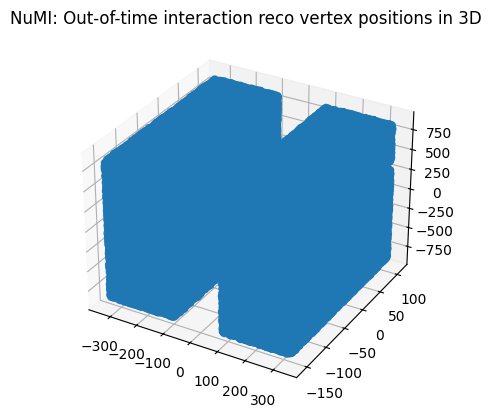

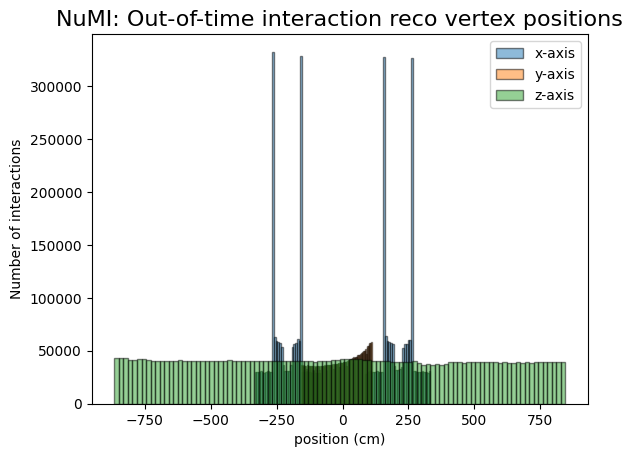

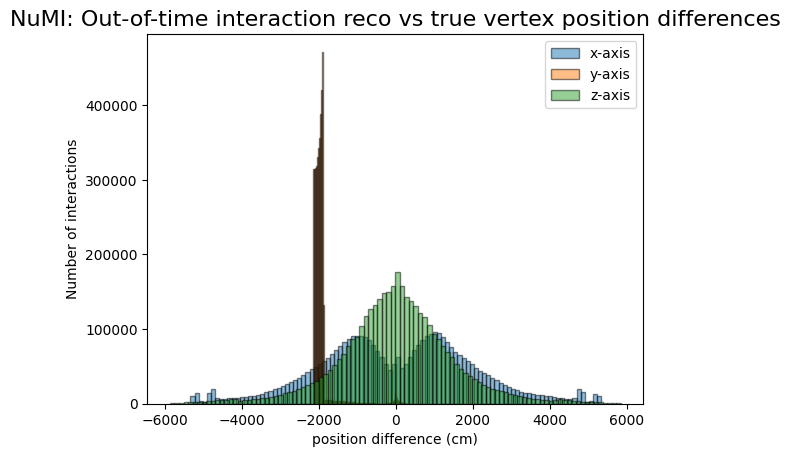

In [76]:
#NuMI_CV_flat_cafs_2_00 
#Out-of-time cosmics analysis

#Importing relevant libraries
import numpy as np
import uproot
import pandas as pd
import hist
import matplotlib.pyplot as plt
import seaborn as sns


#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/All_NuMI_BNB_preselection_cosmics_analysis.root:events/NuMI_simulation/NuMI_fiducial_invertedflashcut_cut_reco"
)

#showing all TBranches
file.keys()

#Extracting and grouping relevant tbranches into a pandas dataframe
recocombinedposition = file.arrays(["reco_vertex_x", "reco_vertex_y", "reco_vertex_z", "true_fiducial_cut"],library="pd")
truecombinedposition = file.arrays(["true_vertex_x", "true_vertex_y", "true_vertex_z", "true_fiducial_cut"],library="pd")

diff = recocombinedposition[["reco_vertex_x", "reco_vertex_y", "reco_vertex_z"]].values - truecombinedposition[["true_vertex_x", "true_vertex_y", "true_vertex_z"]].values
diff_df = pd.DataFrame(diff, columns=["x_diff", "y_diff", "z_diff"])
diff_df.describe()

restricteddiff_df = diff_df[(diff_df["x_diff"] < 1e12) & (diff_df["y_diff"] < 1e12) & (diff_df["z_diff"] < 1e12)]
#plotting interaction vertex positions in 3D
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(recocombinedposition["reco_vertex_x"], recocombinedposition["reco_vertex_y"], recocombinedposition["reco_vertex_z"], 'red', label='Reconstructed vertices')
ax.set_title('NuMI: Out-of-time interaction reco vertex positions in 3D')
plt.show()

plt.hist(recocombinedposition["reco_vertex_x"],bins=100,edgecolor='black',alpha=0.5,label='x-axis')
plt.hist(recocombinedposition["reco_vertex_y"],bins=100,edgecolor='black',alpha=0.5,label='y-axis')
plt.hist(recocombinedposition["reco_vertex_z"],bins=100,edgecolor='black',alpha=0.5,label='z-axis')
plt.xlabel("position (cm)")
plt.ylabel("Number of interactions")
plt.title("NuMI: Out-of-time interaction reco vertex positions", fontsize=16)
plt.legend()
plt.show()

plt.hist(restricteddiff_df["x_diff"],bins=100,edgecolor='black',alpha=0.5,label='x-axis')
plt.hist(restricteddiff_df["y_diff"],bins=100,edgecolor='black',alpha=0.5,label='y-axis')
plt.hist(restricteddiff_df["z_diff"],bins=100,edgecolor='black',alpha=0.5,label='z-axis')
plt.xlabel("position difference (cm)")
plt.ylabel("Number of interactions")
plt.title("NuMI: Out-of-time interaction reco vs true vertex position differences", fontsize=16)
plt.legend()
plt.show()













<h2 style="font-size: 24px;">2. In-time interactions analysis</h2>

<h2 style="font-size: 24px;">2.1 NuMI</h2>

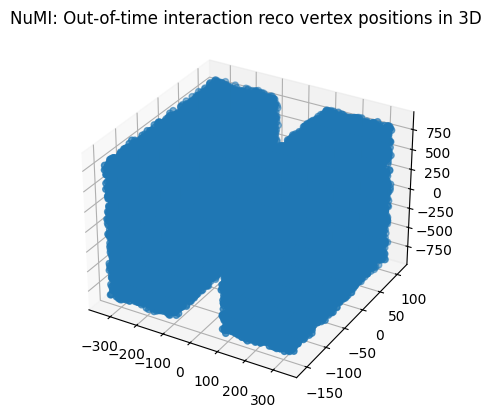

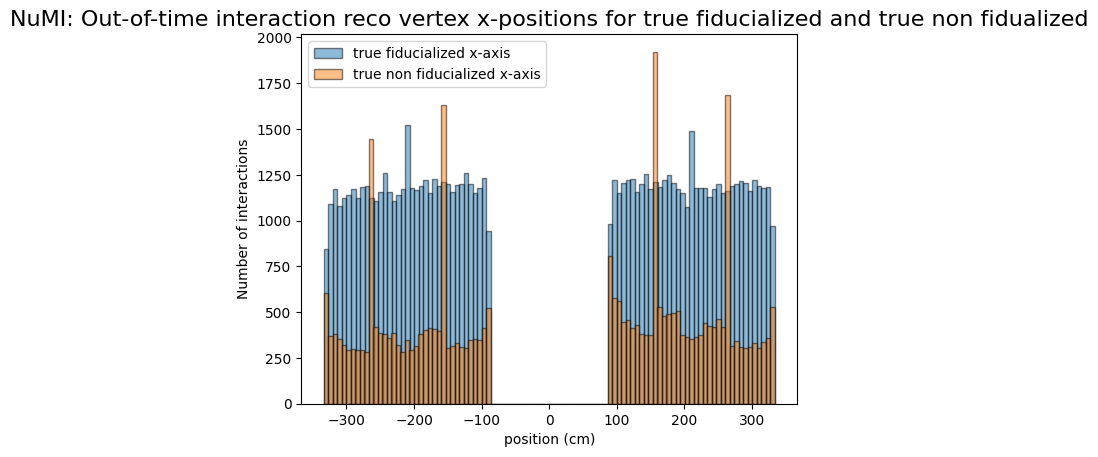

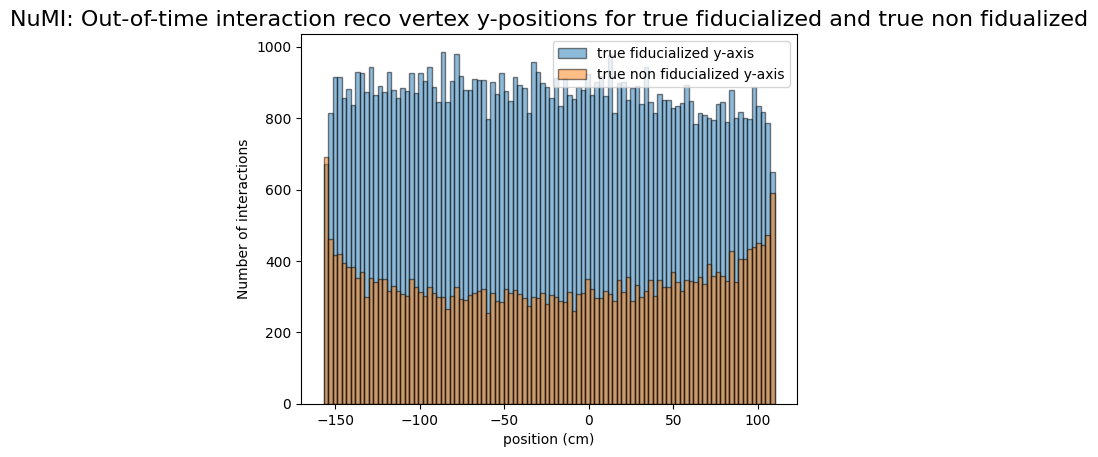

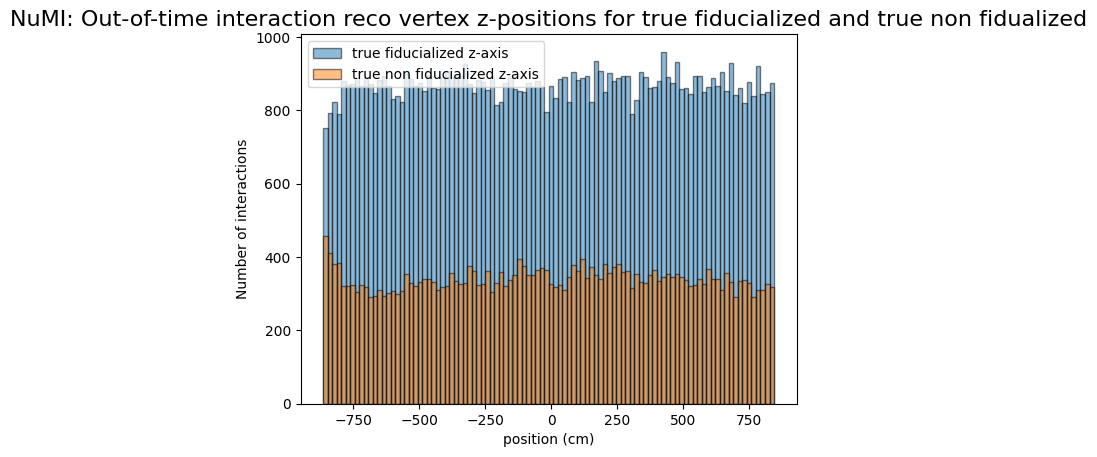

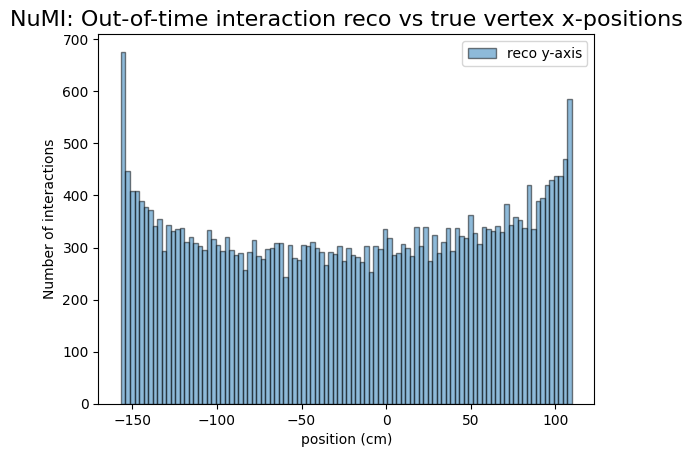

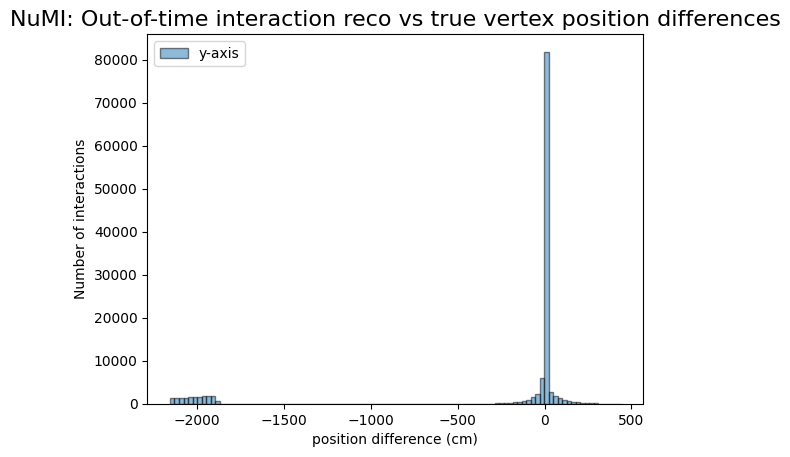

In [ ]:
#NuMI_CV_flat_cafs_2_00 
#Out-of-time cosmics analysis

#Importing relevant libraries
import numpy as np
import uproot
import pandas as pd
import hist
import matplotlib.pyplot as plt
import seaborn as sns


#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/All_NuMI_BNB_preselection_cosmics_analysis.root:events/NuMI_simulation/NuMI_fiducial_flashcut_cut_reco"
)

#showing all TBranches
file.keys()

#Extracting and grouping relevant tbranches into a pandas dataframe
combinedposition = file.arrays(["reco_vertex_x", "reco_vertex_y", "reco_vertex_z", "true_fiducial_cut","true_vertex_x","true_vertex_y","true_vertex_z"],library="pd")
restrictedcombinedposition = combinedposition[(combinedposition["true_vertex_x"] > -1e12) & (combinedposition["true_vertex_y"] > -1e12) & (combinedposition["true_vertex_z"] > -1e12) & (combinedposition["true_fiducial_cut"] == 0)]

recocombinedposition = file.arrays(["reco_vertex_x", "reco_vertex_y", "reco_vertex_z", "true_fiducial_cut"],library="pd")

fiducial_recocombinedposition = recocombinedposition[recocombinedposition["true_fiducial_cut"] == 1]

non_fiducial_recocombinedposition = recocombinedposition[recocombinedposition["true_fiducial_cut"] == 0]

truecombinedposition = file.arrays(["true_vertex_x", "true_vertex_y", "true_vertex_z", "true_fiducial_cut"],library="pd")
restrictedtruecombinedposition = truecombinedposition[(truecombinedposition["true_fiducial_cut"] == 0) & (truecombinedposition["true_vertex_x"] > -1e12)]

diff = recocombinedposition[["reco_vertex_x", "reco_vertex_y", "reco_vertex_z"]].values - truecombinedposition[["true_vertex_x", "true_vertex_y", "true_vertex_z"]].values
diff_df = pd.DataFrame(diff, columns=["x_diff", "y_diff", "z_diff"])
diff_df.describe()

restricteddiff_df = diff_df[(diff_df["x_diff"] < 1e12) & (diff_df["y_diff"] < 1e12) & (diff_df["z_diff"] < 1e12)]
#plotting interaction vertex positions in 3D
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(recocombinedposition["reco_vertex_x"], recocombinedposition["reco_vertex_y"], recocombinedposition["reco_vertex_z"], 'red', label='Reconstructed vertices')
ax.set_title('NuMI: Out-of-time interaction reco vertex positions in 3D')
plt.show()

plt.hist(fiducial_recocombinedposition["reco_vertex_x"],bins=100,edgecolor='black',alpha=0.5,label='true fiducialized x-axis')
plt.hist(non_fiducial_recocombinedposition["reco_vertex_x"],bins=100,edgecolor='black',alpha=0.5,label='true non fiducialized x-axis')
plt.xlabel("position (cm)")
plt.ylabel("Number of interactions")
plt.title("NuMI: Out-of-time interaction reco vertex x-positions for true fiducialized and true non fidualized", fontsize=16)
plt.legend()
plt.show()

plt.hist(fiducial_recocombinedposition["reco_vertex_y"],bins=100,edgecolor='black',alpha=0.5,label='true fiducialized y-axis')
plt.hist(non_fiducial_recocombinedposition["reco_vertex_y"],bins=100,edgecolor='black',alpha=0.5,label='true non fiducialized y-axis')
plt.xlabel("position (cm)")
plt.ylabel("Number of interactions")
plt.title("NuMI: Out-of-time interaction reco vertex y-positions for true fiducialized and true non fidualized", fontsize=16)
plt.legend()
plt.show()

plt.hist(fiducial_recocombinedposition["reco_vertex_z"],bins=100,edgecolor='black',alpha=0.5,label='true fiducialized z-axis')
plt.hist(non_fiducial_recocombinedposition["reco_vertex_z"],bins=100,edgecolor='black',alpha=0.5,label='true non fiducialized z-axis')
plt.xlabel("position (cm)")
plt.ylabel("Number of interactions")
plt.title("NuMI: Out-of-time interaction reco vertex z-positions for true fiducialized and true non fidualized", fontsize=16)
plt.legend()
plt.show()

plt.hist(restrictedcombinedposition["reco_vertex_y"],bins=100,edgecolor='black',alpha=0.5,label='reco y-axis')
#plt.hist(restrictedcombinedposition["true_vertex_y"],bins=100,edgecolor='black',alpha=0.5,label='true y-axis')
plt.xlabel("position (cm)")
plt.ylabel("Number of interactions")
plt.title("NuMI: Out-of-time interaction reco vs true vertex x-positions", fontsize=16)
plt.legend()
plt.show()



#plt.hist(restricteddiff_df["x_diff"],bins=100,edgecolor='black',alpha=0.5,label='x-axis')
plt.hist(restricteddiff_df["y_diff"],bins=100,edgecolor='black',alpha=0.5,label='y-axis')
#plt.hist(restricteddiff_df["z_diff"],bins=100,edgecolor='black',alpha=0.5,label='z-axis')
plt.xlabel("position difference (cm)")
plt.ylabel("Number of interactions")
plt.title("NuMI: Out-of-time interaction reco vs true vertex position differences", fontsize=16)
plt.legend()
plt.show()



In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[ ]:


import jax
import jax.numpy as jnp
from jax import lax, jit, vmap
import matplotlib.pyplot as plt
import time


# In[ ]:


# ==========================================
# 1. Physical Parameters
# ==========================================
T1 = 1.0e-3                 # Longitudinal relaxation time in seconds
T2 = 10.0e-6                 # Transverse relaxation time in seconds
L = 5.0e-3                  # 5 mm medium

OD_target = 1             # Based on Target OD, coupling constant will be calibrated. 

# Grids
Nz = 1000                   # Spatial slices
Nt = 1000                   # Temporal points
N_atoms = 2000              # More like the spectral discretization instead of Number of atoms in the ensemble (cannot be too 1000+ or lower if not absorption graph very coarse)

t = jnp.linspace(0, 15e-6, Nt)  # (JAX, np -> jnp ) 
tau = t / T2                # Dimensionless time
dtau = tau[1] - tau[0]      # Dimensionless time step
dz = L / Nz                 # Spatial step
T1_p = T1 / T2              # Dimensionless T1

sigma_inhom_MHz = 5.5 #inhomogeneous standard dev in MHz
sigma_inhom = 2.0 * jnp.pi * (sigma_inhom_MHz * 1e6) * T2  # Inhomogeneous Broadening (Dimensionless), std dev, 
# To change this value to FWHM, multiply by 2.355

# ==========================================
# 1.1 Beam profile parameters
# ==========================================
N_radial = 31               # Number of radial points for transverse beam profile (number of radial "rings" used to approx the beam cross section)
w0 = 1.0e-3                                     # Beam waist (m)
r_axis = jnp.linspace(0, 2.5 * w0, N_radial)    # Covering 2.5 times of beam waist (radius axis where u sample the beam from centre r=0 out to 2.5w_0)
dr = r_axis[1] - r_axis[0]                      # Radial step size
radial_profile = jnp.exp(-r_axis**2 / w0**2)    # Transverse beam profile (Gaussian)
radial_weights = 2 * jnp.pi * r_axis * dr       # Weight for each radial point (area element in cylindrical coordinates)
radial_weights /= jnp.sum(radial_weights)       # Normalize weights

# ==========================================
# 1.2 AFC memory parameters
# ==========================================

Delta_tooth_MHz=0.2        # spacing between each teeth in MHz
sigma_tooth_MHz=0.017       # tooth width in MHz (FWHM = 2.355*sigma)
n_teeth = 10               # total teeth = 21 across the envelope (one in the middle, then 20 on each left n right side)
d_bg = 0.00                # 0% background (make it to 0 if u simulate a perfect comb)

Delta_tooth = 2.0 * jnp.pi * (Delta_tooth_MHz * 1e6) * T2      # tooth spacing = 1 MHz (converted to dimensionless)
gamma_tooth = 2.0 * jnp.pi * (sigma_tooth_MHz * 1e6) * T2      # tooth width std-dev = 0.2 MHz (dimensionless)

# ==========================================
# 1.3 Input pulse for AFC memory  
# ==========================================

# Pulse Shape 
def tanh_pulse(time, pulse_start, pulse_duration, rise, peak):
    pulse = peak * 0.5 * (jnp.tanh((time - pulse_start)/rise) - jnp.tanh((time - pulse_start - pulse_duration)/rise))
    return pulse.astype(jnp.complex64)
#need to properly choose the parameteres. rmb the input pulse needs to be wide/ long enuf to cover the AFC so that it can be absorbed. and also take note of the time axis needed based on the order of magnitude of the echo and comb width

# Generate Input Pulse
pulse_start= 1e-6
pulse_duration= 1e-6
p1 = tanh_pulse(t, pulse_start, pulse_duration, 0.05e-6, 2 * jnp.pi * 0.05e6) 
omega_in = p1 * T2  # Dimensionless input pulse

# Predicted AFC echo time (for 2-level AFC echo)
gamma_fwhm_MHz = 2.355 * sigma_tooth_MHz
F = Delta_tooth_MHz / gamma_fwhm_MHz                           # finesse
t_pulse_centre = (pulse_start + (pulse_duration / 2)) * 1e6    # in microseconds
t_echo = 1.0 / Delta_tooth_MHz                                 # in microseconds

print(f"Predicted AFC echo time after input pulse: 1/Δ = {t_echo:.3f} µs")
print(f"pulse duration = {pulse_duration*1e6:.3f} µs")
print(f"So expected echo around: { (t_pulse_centre + t_echo):.3f} µs")
print(f"finesse F = {F:.2f} (want ~3 - 10, 5 is good)")
print(f"pulse/echo ratio = {(pulse_duration*1e6) / t_echo:.3f} (want ~0.1 – 0.3)")


# In[ ]:


# =============================
# 2. AFC spectral distribution
# =============================
def afc_profile(dist_range,
                     sigma_inhom,      # envelope std-dev (dimensionless)
                     Delta_tooth,    # tooth spacing (dimensionless)
                     gamma_tooth,    # tooth std-dev (dimensionless)
                     n_teeth,        # number of teeth on ONE side (total = 2*n_teeth+1)
                     d_bg,OD_target):      # background fraction in [0,1]
    """
    Returns g_AFC(dist_range) (not normalized) on the same grid.
    All frequency-like parameters here are in the SAME units as dist_range
    (in your code, dist_range is dimensionless detuning = (Hz*2π*T2)).
    """

    # 1) Envelope (Gaussian inhomogeneous line)
    g_env = jnp.exp(-0.5 * (dist_range / sigma_inhom) ** 2)

    # 2) Comb: sum of Gaussian teeth centered at j*Delta_tooth
    j_idx = jnp.arange(-n_teeth, n_teeth + 1)  # shape (2*n_teeth+1,)
    centers = j_idx * Delta_tooth              # tooth centers

    # Build comb by summing exp(-(δ - center)^2/(2*gamma_tooth^2)) over centers
    # Broadcasting: dist_range[:,None] minus centers[None,:]
    comb = jnp.sum(jnp.exp(-0.5 * ((dist_range[:, None] - centers[None, :]) / gamma_tooth) ** 2),
                   axis=1)

    # 3) Add background (optional)
    #g_afc = g_env * ((OD_target - d_bg) * comb + d_bg)
    g_afc = ((OD_target - d_bg) * comb * g_env) + d_bg

    return g_afc


# In[ ]:


# ==========================================
# 3. Calibrate coupling kappa so that center transmission matches exp(-OD_target)
# ==========================================

def get_analytical_coupling_AFC(OD_target, sigma_inhom, Delta_tooth, gamma_tooth, n_teeth, d_bg, N_atoms, L):
    # Detuning grid in dimensionless units; cover the envelope well
    dist_range = jnp.linspace(-3.0 * sigma_inhom, 3.0 * sigma_inhom, N_atoms)

    # AFC weights (normalized so sum(weights)=1)
    prof = afc_profile(dist_range, sigma_inhom, Delta_tooth, gamma_tooth, n_teeth, d_bg, OD_target)
    weights = prof / jnp.sum(prof)

    # Response sum: steady-state susceptibility factor in your dimensionless model
    response_sum = jnp.sum(weights / (1.0 + 1j * dist_range))

    # Choose kappa so the exponential attenuation matches target OD.
    # (Keeping your original style: kappa can be complex; transmission uses Re[kappa * L * S])
    kappa = (OD_target / L) / response_sum
    return kappa

calibrated_coupling = get_analytical_coupling_AFC(OD_target, sigma_inhom, Delta_tooth, gamma_tooth, n_teeth, d_bg, N_atoms, L)
print("Calibrated coupling kappa =", calibrated_coupling)



# In[ ]:


# ==============================
# 4. Transmission spectrum with AFC
# ==============================
def get_analytical_spectrum_AFC(scan_range_hz, kappa, sigma_inhom, Delta_tooth, gamma_tooth, n_teeth, d_bg, N_atoms, L):
    
    # Detuning grid for the ensemble
    dist_range = jnp.linspace(-3.0 * sigma_inhom, 3.0 * sigma_inhom, N_atoms)

    # AFC weights
    prof = afc_profile(dist_range, sigma_inhom, Delta_tooth, gamma_tooth, n_teeth, d_bg, OD_target)
    weights = prof / jnp.sum(prof)

    # Convert scan detuning (Hz) -> dimensionless delta = (2π * Hz * T2)
    delta_scan = scan_range_hz * 2.0 * jnp.pi * T2
    
    # Compute susceptibility-like sum over ensemble detunings
    # atoms have detunings dist_range; probe detuning shifts them by -delta
    def compute_s(delta):
        return jnp.sum(weights / (1.0 + 1j * (dist_range - delta)))

    s_vals = vmap(compute_s)(delta_scan)

    # Transmission
    transmission = jnp.exp(-jnp.real(kappa * L * s_vals))
    return transmission

# JIT compile (avoid decorator form that caused your "jit() missing fun" error)
get_analytical_spectrum_AFC = jax.jit(get_analytical_spectrum_AFC,static_argnames=("N_atoms", "n_teeth"))

scan_range_hz = jnp.linspace(-3e6, 3e6, 2000) # Setting the scan range in Hz and number of points
t_spectrum = get_analytical_spectrum_AFC(scan_range_hz,calibrated_coupling,sigma_inhom,Delta_tooth,gamma_tooth,n_teeth,d_bg,N_atoms,L)
od_spectrum = -jnp.log(jnp.clip(t_spectrum, 1e-12, 1.0))

print(f"Predicted AFC comb teeth width in time domain: 1/σ = {1.0 / sigma_tooth_MHz:.3f} µs")

# ==========================================
# 4.1 Plotting
# ==========================================

# =====1. OD plot=====

#Convert scan axis to MHz for plotting
scan_MHz = scan_range_hz / 1e6

plt.figure(figsize=(7, 4))
plt.plot(scan_MHz, od_spectrum, color="darkgreen", lw=2, label="AFC optical depth")

plt.axhline(float(OD_target), color="red", linestyle="--", alpha=0.6,
            label=f"OD_target = {OD_target}")

plt.title(
    "AFC Optical Depth Spectrum\n"
    f"OD={OD_target}, sigma_env={sigma_inhom_MHz:.1f} MHz, Δ={Delta_tooth_MHz:.2f} MHz, "
    f"tooth σ={sigma_tooth_MHz:.2f} MHz, d_bg={d_bg}"
)
plt.xlabel("Probe Detuning (MHz)")
plt.ylabel("Optical Depth  OD(Δ) = -ln(T)")
plt.ylim(0.0, None)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =====2.Transimission plot=====
# Convert scan axis to MHz for plotting
scan_MHz = scan_range_hz / 1e6

plt.figure(figsize=(7, 4))
plt.plot(scan_MHz, t_spectrum, color="forestgreen", lw=2, label="AFC analytical transmission")

# Reference line: exp(-OD_target)
plt.axhline(float(jnp.exp(-OD_target)), color="red", linestyle="--", alpha=0.6,
            label=f"exp(-OD) at center = {float(jnp.exp(-OD_target)):.3f}")

plt.title(
    "AFC Transmission Spectrum\n"
    f"OD={OD_target}, sigma_env={sigma_inhom_MHz:.1f} MHz, Δ={Delta_tooth_MHz:.2f} MHz, "
    f"tooth σ={sigma_tooth_MHz:.2f} MHz, d_bg={d_bg}"
)
plt.xlabel("Probe Detuning (MHz)")
plt.ylabel("Transmission")
plt.ylim(0.0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# In[ ]:


# ==========================================
# 5. Solver & Ensemble Kernels
# ==========================================

@jit
def master_eq_step(rho, Om, Delta_val, dt):
    def rhs(rho_val, Om_val):
        r11, r22, r21 = rho_val
        dr21 = -(1j * Delta_val + 1.0) * r21 + 0.5j * Om_val * (r11 - r22)
        dr22 = -r22 / T1_p + jnp.imag(jnp.conj(Om_val) * r21)
        dr11 = -dr22
        return jnp.array([dr11, dr22, dr21], dtype=jnp.complex64)
    k1 = rhs(rho, Om); k2 = rhs(rho + dt/2*k1, Om)
    k3 = rhs(rho + dt/2*k2, Om); k4 = rhs(rho + dt*k3, Om)
    return rho + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

@jit
def solve_ensemble_with_beam(Omega_slice, detuning_array, weights, radial_profile, radial_weights): #solve bloch dynamics of all detuning classes for one spatial position z
    omega_grid=jnp.outer(radial_profile, Omega_slice) #(N_radial, Nt)
    
    def compute_radial_contribution(local_omega_slice): #solve inhomogeneous ensemble response for one radius
        init_states = jnp.tile(jnp.array([1.0+0j, 0, 0], dtype=jnp.complex64), (N_atoms, 1)) #creating a state for every detuning class 
        def atom_scan(states, Om_val): #define one time step of the ensemble evolution
            next_states = vmap(master_eq_step, in_axes=(0, None, 0, None))(states, Om_val, detuning_array, dtau) #vmap applies master_eq_step in parallel to all detuning classes, integrates the bloch equations for each detuning and same driving field
            avg_rho21 = jnp.sum(next_states[:, 2] * weights) #extracts column 2 which is rho_21, then do a weighted sum over the detunings
            return next_states, avg_rho21 #return updated states and polarisation
    
        _, ensemble_rho21 = lax.scan(atom_scan, init_states, local_omega_slice) #lax.scan propagates states forward in time and collect ensemble coherence at each time step
        return ensemble_rho21 #ensemble averaged coherence <rho_21(t)> over time
    
    # Use vmap to solve for all radial rings simultaneously
    # rho21_radial_matrix shape: (N_radial, Nt)
    rho21_radial_matrix = vmap(compute_radial_contribution)(omega_grid)

    # Weighted sum over radial dimensions
    final_avg_rho21 = jnp.sum(rho21_radial_matrix * radial_weights[:, None], axis=0)
    return final_avg_rho21

#############################################################################
################## Added function to return full histories ##################
######### No need this part if individual atomic states are not needed ######
#############################################################################
@jit
def solve_ensemble_beam_full(Omega_slice, detuning_array, weights, radial_profile, radial_weights):
    omega_grid = jnp.outer(radial_profile, Omega_slice) # (N_radial, Nt)

    def compute_radial_contribution(local_omega_slice):
        init_states = jnp.tile(jnp.array([1.0+0j, 0, 0], dtype=jnp.complex64), (N_atoms, 1))
        def atom_scan(states, Om_val):
            next_states = vmap(master_eq_step, in_axes=(0, None, 0, None))(states, Om_val, detuning_array, dtau)
            avg_rho21 = jnp.sum(next_states[:, 2] * weights)
            return next_states, (avg_rho21, next_states[:, 2])                           # Return both ensemble average and individual value for rho21 
    
        _, (ensemble_rho21, atomic_history) = lax.scan(atom_scan, init_states, local_omega_slice) # Indentation should be alighned with return.  
        return ensemble_rho21, atomic_history
    
    # 1. Vmap parallel computation over radial positions
    # rho21_radial_matrix: (N_radial, Nt)
    # atomic_histories: (N_radial, Nt, N_atoms)
    rho21_radial_matrix, atomic_histories = vmap(compute_radial_contribution)(omega_grid) 

    # 2. ensemble average rho21 for Maxwell eq. propagation
    final_avg_rho21 = jnp.sum(rho21_radial_matrix * radial_weights[:, None], axis=0) 
    
    # 3. ensemble average rho21 history for heatmap
    # (N_radial, Nt, N_atoms) * (N_radial, 1, 1) -> sum over radial axis
    radially_averaged_history = jnp.sum(atomic_histories * radial_weights[:, None, None], axis=0) 
    
    return final_avg_rho21, radially_averaged_history


# In[ ]:


# ==========================================
# 6. Propagation 
# ==========================================
@jit
def propagate_field(initial_omega, delta_offset=0.0):
    dist_range = jnp.linspace(-3*sigma_inhom, 3*sigma_inhom, N_atoms)
    detuning_array = dist_range + delta_offset
    
    # AFC weights
    prof = afc_profile(dist_range, sigma_inhom, Delta_tooth, gamma_tooth, n_teeth, d_bg, OD_target)
    weights = prof / jnp.sum(prof)
    
    def scan_body(Omega_curr, _): #define one step in z
        # 1. Predictor 
        rho21_avg = solve_ensemble_with_beam(Omega_curr, detuning_array, weights, radial_profile, radial_weights) #solve bloch eqn for all detunings and get ensemble averaged coherence
        # ∂Ω/∂z = i * kappa * rho_21
        Omega_pred = Omega_curr + dz * 1j * calibrated_coupling * rho21_avg
        
        # 2. Corrector 
        rho21_pred = solve_ensemble_with_beam(Omega_pred, detuning_array, weights, radial_profile, radial_weights)
        Omega_next = Omega_curr + dz * 1j * calibrated_coupling * 0.5 * (rho21_avg + rho21_pred)
        
        return Omega_next, Omega_next

    _, history = lax.scan(scan_body, initial_omega, jnp.arange(Nz)) #loops over Nz spatial steps
    return jnp.vstack([initial_omega[None, :], history])

#############################################################################
################## Added function to return full histories ##################
######### No need this part if individual atomic states are not needed ######
#############################################################################
@jit
def propagate_and_get_states(initial_omega):
    dist_range = jnp.linspace(-3*sigma_inhom, 3*sigma_inhom, N_atoms)
    
    # AFC weights
    prof = afc_profile(dist_range, sigma_inhom, Delta_tooth, gamma_tooth, n_teeth, d_bg, OD_target)
    weights = prof / jnp.sum(prof)
    
    def scan_body(Omega_curr, _):
        # Field propagation only requires ensemble average
        rho21_avg, _ = solve_ensemble_beam_full(Omega_curr, dist_range, weights, radial_profile, radial_weights)
        Omega_pred = Omega_curr + dz * 1j * calibrated_coupling * rho21_avg
        rho21_pred, _ = solve_ensemble_beam_full(Omega_pred, dist_range, weights, radial_profile, radial_weights)
        Omega_next = Omega_curr + dz * 1j * calibrated_coupling * 0.5 * (rho21_avg + rho21_pred)
        return Omega_next, Omega_next

    final_field, _ = lax.scan(scan_body, initial_omega, jnp.arange(Nz))
    _, atomic_rho21_history = solve_ensemble_beam_full(final_field, dist_range, weights, radial_profile, radial_weights) # Get the full atomic states history at the final slice
    return final_field, atomic_rho21_history


# In[ ]:


# ==========================================
# 7. Execution 
# ==========================================

################################################
######### Include heatmap data #################
################################################
include_heatmap = True  # Set to True to get rho21 heatmap data

print("Running Simulation...")
start_time = time.time()

if include_heatmap:
    omega_out, rho21_heatmap_data = propagate_and_get_states(omega_in)
    omega_out = omega_out.block_until_ready()
    rho21_heatmap_data = rho21_heatmap_data.block_until_ready()
else:
    omega_out = propagate_field(omega_in).block_until_ready()
    rho21_heatmap_data = None

end_time = time.time()
duration = end_time - start_time

print(f"Simulation Completed. (Time: {duration}s)")


# In[ ]:


# ==========================================
# 8. Visualization 
# ==========================================


# Convert Omega to MHz for plotting
Omega_input_MHz = jnp.abs(omega_in) / (T2 * 2 * jnp.pi * 1e6)
if omega_out.ndim == 2:
    Omega_output_MHz = jnp.abs(omega_out[-1, :]) / (T2 * 2 * jnp.pi * 1e6)
else:
    Omega_output_MHz = jnp.abs(omega_out) / (T2 * 2 * jnp.pi * 1e6)


#####################
# Time vs |Rabi|^2
#####################
plt.figure(figsize=(8, 4))
plt.plot(t * 1e6, Omega_input_MHz**2, 'b--', linewidth=1.5, label='Input Pulse (z=0)')
plt.plot(t * 1e6, Omega_output_MHz**2, 'r-', linewidth=1.5, label=f'Output Pulse (OD={OD_target})')
plt.title('Pulse Propagation: Input vs Output Intensity', fontsize=14)
plt.xlabel('Time (μs)', fontsize=12)
plt.ylabel('Intensity (arb unit)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#####################
# Time vs |Rabi|
#####################
plt.figure(figsize=(8, 4))
plt.plot(t * 1e6, Omega_input_MHz, 'b--', linewidth=1.5, label='Input Pulse (z=0)')
plt.plot(t * 1e6, Omega_output_MHz, 'r-', linewidth=1.5, label=f'Output Pulse (OD={OD_target})')
plt.title('Pulse Propagation: Input vs Output |Rabi|', fontsize=14)
plt.xlabel('Time (μs)', fontsize=12)
plt.ylabel('|Rabi|/2pi (MHz)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


######################
# Heatmap of rho21
######################
if rho21_heatmap_data is not None:
    detuning_axis = jnp.linspace(-3*sigma_inhom, 3*sigma_inhom, N_atoms)
    detuning_mhz = detuning_axis / (2 * jnp.pi * T2) / 1e6 # Dimensionless to MHz
    T_mesh, D_mesh = jnp.meshgrid(t * 1e6, detuning_mhz)   # Time (μs) vs Detuning (MHz)
    
    ########## Real rho21 Heatmap ##########
    plt.figure(figsize=(8, 4))
    im = plt.pcolormesh(T_mesh, D_mesh, jnp.real(rho21_heatmap_data).T, 
                    cmap='seismic', vmin=-0.25, vmax=0.25, shading='gouraud')
    cbar = plt.colorbar(im)
    cbar.set_label("Real Part of Coherence ($Re(\\rho_{21})$)", fontsize=10)
    plt.title("Atomic Ensemble State Evolution", fontsize=13)
    plt.xlabel("Time (μs)", fontsize=11)
    plt.ylabel("Detuning (MHz)", fontsize=11)
    plt.grid(True, alpha=0.2, color='grey')
    plt.tight_layout()
    
    ########## Angle rho21 Heatmap ########## (to show phase evolution of atomic optical coherence in the ensemble over time and for each detuning class)
    plt.show()
    plt.figure(figsize=(8, 4))
    im = plt.pcolormesh(T_mesh, D_mesh, jnp.angle(rho21_heatmap_data).T, 
                    cmap='hsv', vmin=-jnp.pi, vmax=jnp.pi, shading='gouraud')
    cbar = plt.colorbar(im)
    cbar.set_label("Arg. of Coherence ($Arg(\\rho_{21})$)", fontsize=10)
    plt.title("Atomic Ensemble State Evolution", fontsize=13)
    plt.xlabel("Time (μs)", fontsize=11)
    plt.ylabel("Detuning (MHz)", fontsize=11)
    plt.grid(True, alpha=0.2, color='grey')
    plt.tight_layout()
    plt.show()


# In[ ]:


# ==========================================
# 9. Efficiency calculation 
# ==========================================

def window_integral(t, y, t1, t2):
    """Integrate y(t) over [t1,t2] using trapezoid rule."""
    mask = (t >= t1) & (t <= t2)
    tt = t[mask]
    yy = y[mask]
    return jnp.where(tt.size > 1, jnp.trapezoid(yy, tt), 0.0)

def afc_efficiency_from_echo(
    t,
    omega_in,
    omega_out,
    pulse_start,
    pulse_duration,
    rise_time,          # <-- pass this in instead of hardcoding 0.05e-6
    Delta_tooth_MHz,
    echo_index=1,
    echo_window_factor=0.25,  # smaller is often safer
    subtract_leakage=True
):
    # ---- Input energy window ----
    margin = 3.0 * rise_time
    t_in1 = pulse_start - margin
    t_in2 = pulse_start + pulse_duration + margin
    Ein = window_integral(t, jnp.abs(omega_in)**2, t_in1, t_in2)

    # ---- Echo window ----
    T_echo = 1.0 / (Delta_tooth_MHz * 1e6)  # seconds
    t_center = (pulse_start + 0.5 * pulse_duration) + echo_index * T_echo
    half = echo_window_factor * T_echo
    t_e1 = t_center - half
    t_e2 = t_center + half

    Iout = jnp.abs(omega_out)**2
    Eecho_raw = window_integral(t, Iout, t_e1, t_e2)

    if subtract_leakage:
        # pick baseline window AFTER input, BEFORE echo
        gap = 2.0 * rise_time
        pre1 = t_in2 + gap
        pre2 = t_e1 - gap

        # need a valid, non-empty baseline window
        if (pre2 > pre1):
            Epre = window_integral(t, Iout, pre1, pre2)
            Tpre = jnp.maximum(pre2 - pre1, 1e-15)
            Pbg = Epre / Tpre
            Eecho = jnp.maximum(Eecho_raw - Pbg * (t_e2 - t_e1), 0.0)
        else:
            # no clean baseline region available → don’t subtract
            Eecho = Eecho_raw
    else:
        Eecho = Eecho_raw

    eta = jnp.where(Ein > 0, Eecho / Ein, 0.0)
    return eta, Ein, Eecho, t_center, (t_e1, t_e2)

omega_out_final = omega_out[-1, :] if omega_out.ndim == 2 else omega_out

eta1, Ein, Eecho1, t_center1, (t_e1, t_e2) = afc_efficiency_from_echo(
    t=t,
    omega_in=omega_in,
    omega_out=omega_out_final,
    pulse_start=pulse_start,
    pulse_duration=pulse_duration,
    rise_time=0.05e-6,
    Delta_tooth_MHz=Delta_tooth_MHz,
    echo_index=1,
    echo_window_factor=0.25,
    subtract_leakage=True
)

print(f"1st-echo center ~ {t_center1*1e6:.3f} µs")
print(f"echo window ~ [{t_e1*1e6:.3f}, {t_e2*1e6:.3f}] µs")
print(f"Ein={float(Ein):.3e}, Eecho={float(Eecho1):.3e}, eta={float(eta1):.4f}")

ModuleNotFoundError: No module named 'jax'